In [8]:
# Connect Google Colab
from google.colab import files

uploaded = files.upload()  # This will open a file picker
import pandas as pd

df = pd.read_csv('survey_results_public.csv')
df.head()
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

/tmp/ipython-input-3383993190.py:7: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('survey_results_public.csv')  # same name as uploaded file


In [10]:
# Business Understanding: We want to understand what drives a high salary (> $100k) for developers.
# Question 1: How does years of professional coding experience relate to salary?
# Question 2: Does formal education level significantly impact earning a high salary?
# Question 3: Can we predict if a developer earns over $100k based on their background?
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [12]:
# Search for the correct column names
print("--- Looking for Years of Coding ---")
for col in df.columns:
    if 'Year' in col or 'Code' in col:
        print(col)

print("\n--- Looking for Education ---")
for col in df.columns:
    if 'Ed' in col:
        print(col)

print("\n--- Looking for Salary/Compensation ---")
for col in df.columns:
    if 'Comp' in col:
        print(col)

--- Looking for Years of Coding ---
LearnCodeChoose
LearnCode
LearnCodeAI
YearsCode
ConvertedCompYearly

--- Looking for Education ---
EdLevel

--- Looking for Salary/Compensation ---
CompTotal
AIComplex
ConvertedCompYearly


In [13]:
def clean_data(df):
    """
    Cleans the StackOverflow dataset for modeling.
    - Drops rows missing target variable (salary).
    - Creates a binary target variable (>100k USD).
    - Selects key features.
    - Imputes missing numerical values.
    - Dummifies categorical variables.
    """
    target_col = 'ConvertedCompYearly'
    features = ['YearsCode', 'EdLevel', 'OrgSize']

    # Drop rows where target is missing
    df = df.dropna(subset=[target_col])

    # Create Binary Target: 1 if > 100,000 USD, else 0
    y = (df[target_col] > 100000).astype(int)

    # Filter features
    X_raw = df[features].copy()


    # StackOverflow sometimes uses these text strings, so we convert them to numbers
    X_raw['YearsCode'] = X_raw['YearsCode'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
    X_raw['YearsCode'] = pd.to_numeric(X_raw['YearsCode'], errors='coerce')

    # Impute missing numerical values with the median
    num_imputer = SimpleImputer(strategy='median')
    X_raw['YearsCode'] = num_imputer.fit_transform(X_raw[['YearsCode']])

    # Handle Categorical Variables using One-Hot Encoding
    categorical_cols = ['EdLevel', 'OrgSize']
    X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

    return X, y

# Clean data
X, y = clean_data(df)

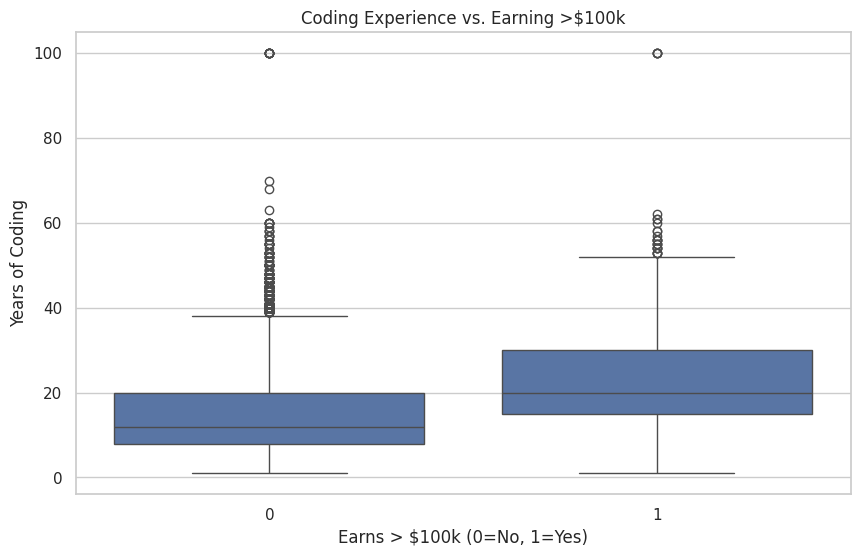

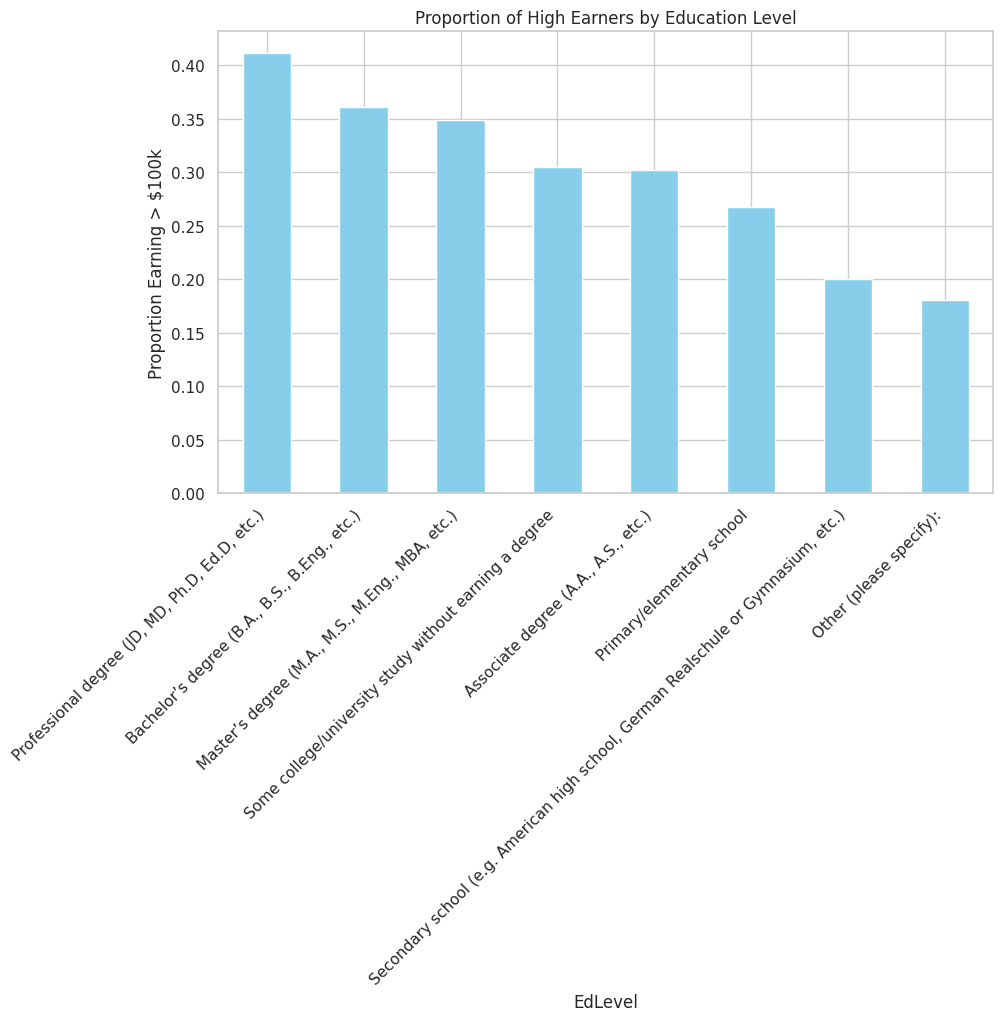

In [14]:
# Q1: Salary vs. Years of Experience
plt.figure(figsize=(10, 6))
sns.boxplot(x=y, y=X['YearsCode'])
plt.title('Coding Experience vs. Earning >$100k')
plt.xlabel('Earns > $100k (0=No, 1=Yes)')
plt.ylabel('Years of Coding')
plt.show()

# Q2: Formal Education Impact
ed_sal = df.dropna(subset=['ConvertedCompYearly', 'EdLevel']).copy()
ed_sal['HighEarner'] = (ed_sal['ConvertedCompYearly'] > 100000).astype(int)
ed_grouped = ed_sal.groupby('EdLevel')['HighEarner'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ed_grouped.plot(kind='bar', color='skyblue')
plt.title('Proportion of High Earners by Education Level')
plt.ylabel('Proportion Earning > $100k')
plt.xticks(rotation=45, ha='right')
plt.show()

Model Accuracy: 0.6807237299930411

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.82      0.77      4722
           1       0.55      0.41      0.47      2463

    accuracy                           0.68      7185
   macro avg       0.64      0.62      0.62      7185
weighted avg       0.66      0.68      0.67      7185



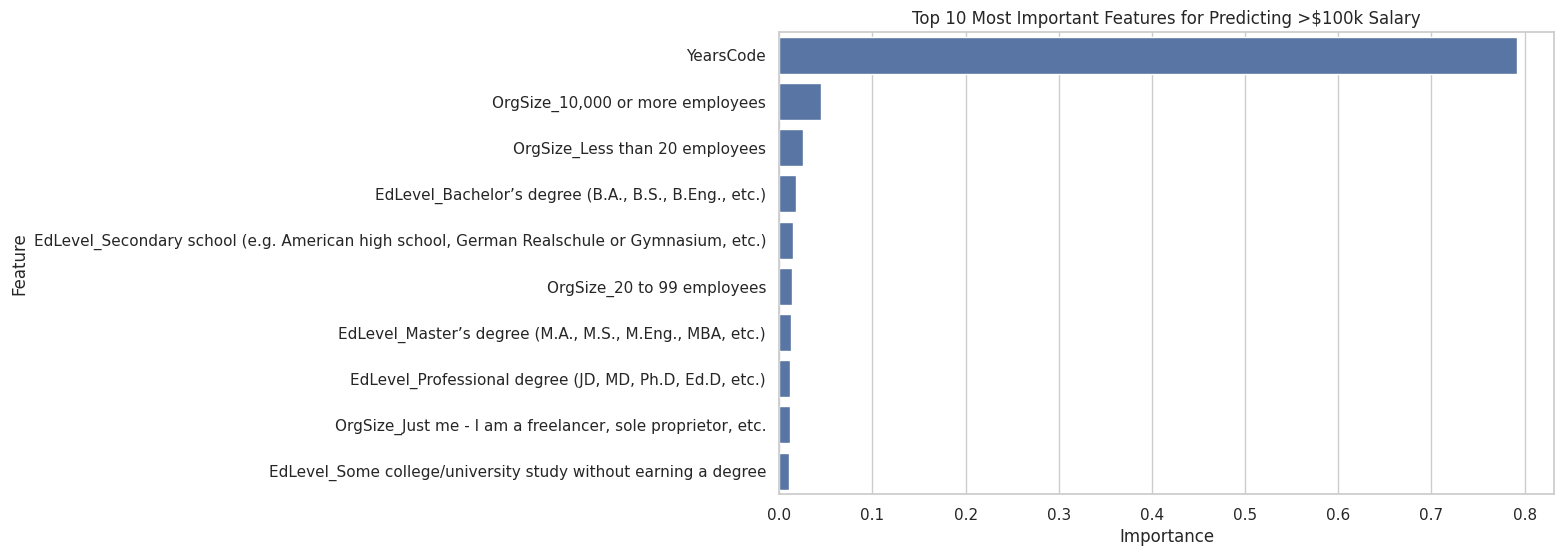

In [16]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier (THIS is where 'model' is defined!)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Get Feature Importances to answer "What drives the predicted outcome?"
importances = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10))
plt.title('Top 10 Most Important Features for Predicting >$100k Salary')
plt.show()

In [17]:
# Scenario: A developer with 5 years experience.
scenario = pd.DataFrame(np.zeros((1, len(X.columns))), columns=X.columns)
scenario['YearsCode'] = 5

# Dynamically find the matching columns for Master's Degree and 10k+ employees
master_col = [col for col in X.columns if 'Master’s degree' in col or 'Master' in col]
if master_col:
    scenario[master_col[0]] = 1

org_col = [col for col in X.columns if '10,000 or more' in col]
if org_col:
    scenario[org_col[0]] = 1

prediction = model.predict(scenario)
probability = model.predict_proba(scenario)[0][1]

print(f"Prediction (1 = >$100k, 0 = <=$100k): {prediction[0]}")
print(f"Probability of earning >$100k: {probability * 100:.2f}%")

Prediction (1 = >$100k, 0 = <=$100k): 0
Probability of earning >$100k: 0.00%
